In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import os 

%matplotlib inline

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

sns.set_theme(style= "whitegrid", palette= "muted")
plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["figure.dpi"] = 120

In [2]:
#Carga de datos limpios

DATA_PATH = os.path.join("..", "data", "processed", "lima_properties_clean.csv")
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print(f"El data set tiene {df.shape[0]} filas y {df.shape[1]} columnas")
print(F"\n")
print(df.dtypes)
df.head()

El data set tiene 3987 filas y 11 columnas


listing_id           int64
district               str
price_pen          float64
maintenance_fee    float64
area_total         float64
bedrooms             int64
bathrooms            int64
parking_spaces       int64
address                str
urbanization           str
photos_count         int64
dtype: object


,listing_id,district,price_pen,maintenance_fee,area_total,bedrooms,bathrooms,parking_spaces,address,urbanization,photos_count
0,149387506,ate,759000.00,0.00,194.00,4,3,1,Edificio Sabadell con Badajoz,Mayorazgo,10
1,148003136,ate,725000.00,0.00,124.00,3,3,0,Los Olmos Salamanca de Monterrico,Salamanca De Monterrico,10
2,149149198,ate,404168.00,0.00,126.00,3,2,0,Av. Marginal al 100,Javier Prado Et.6,10
3,148288992,ate,463500.00,100.00,107.00,3,2,0,Salamanca de Monterrico,Salamanca De Monterrico,1
4,149365027,ate,720000.00,120.00,136.00,3,3,1,Salamanca de Monterrico,Salamanca De Monterrico,1


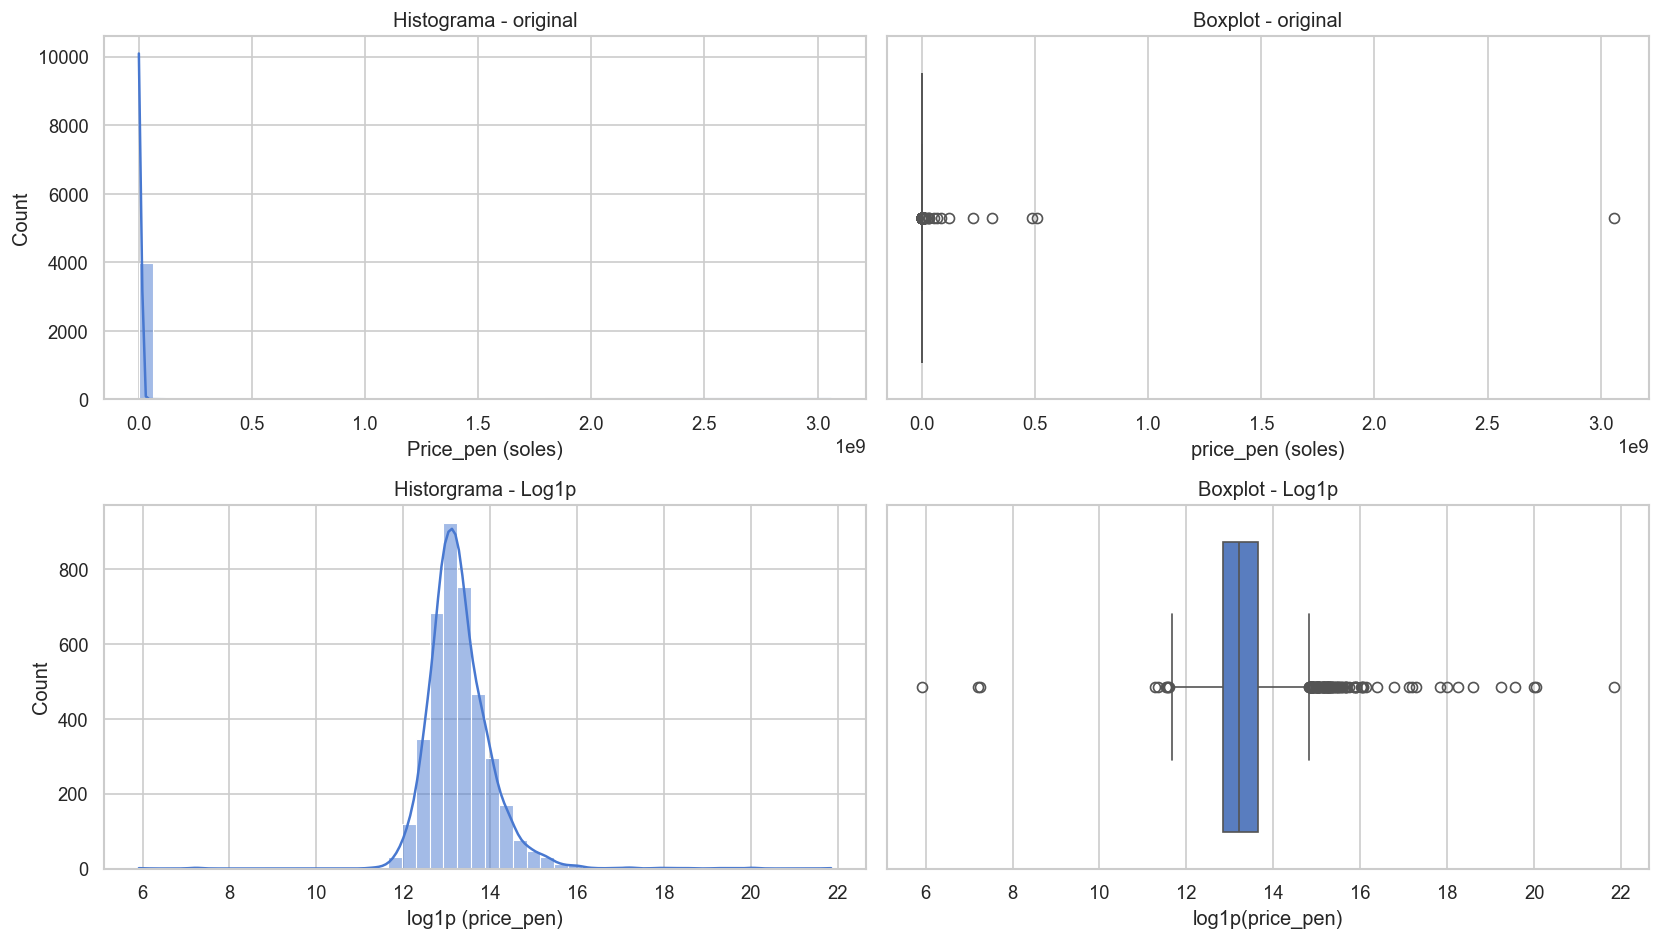

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))

#Histograma original
sns.histplot(df["price_pen"], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title("Histograma - original")
axes[0,0].set_xlabel("Price_pen (soles)")

#Boxplot original
sns.boxplot(x=df["price_pen"], ax=axes[0,1])
axes[0,1].set_title("Boxplot - original")
axes[0,1].set_xlabel("price_pen (soles)")

#Histograma log1p
sns.histplot(np.log1p(df["price_pen"]), bins=50, kde=True, ax=axes[1,0])
axes[1,0].set_title("Historgrama - Log1p")
axes[1,0].set_xlabel("log1p (price_pen)")

# Boxplot log1p
sns.boxplot(x=np.log1p(df["price_pen"]), ax=axes[1, 1])
axes[1, 1].set_title("Boxplot - Log1p")
axes[1, 1].set_xlabel("log1p(price_pen)")


plt.tight_layout()
plt.show()


In [4]:
# HALLAZGO EDA - Outliers en price_pen
# Distribución original: sesgo pronunciado a la derecha (right-skewed)
# Outliers detectados visualmente: valores cercanos a 3,000M soles (scraping error)
# Outliers en cola izquierda: valores < 1,000 soles (scraping error)
# Decisión: aplicar filtro 3*IQR sobre log1p(price_pen) al final del notebook
# Transformación log1p confirmada como necesaria para modelado

In [5]:
var_num = ["price_pen", "maintenance_fee", "area_total", 
           "bedrooms", "bathrooms", "parking_spaces", "photos_count"]

percentiles = [0.10, 0.25, 0.50, 0.75, 0.90]

df[var_num].describe(percentiles=percentiles).round(2)

,price_pen,maintenance_fee,area_total,bedrooms,bathrooms,parking_spaces,photos_count
count,3987.00,3987.00,3987.00,3987.00,3987.00,3987.00,3987.00
mean,2016381.62,552.28,120.12,2.65,2.17,0.78,1.82
std,50156303.72,21622.07,92.04,0.92,0.92,0.93,2.58
min,370.00,0.00,21.00,1.00,1.00,0.00,1.00
10%,278736.00,0.00,51.00,1.00,1.00,0.00,1.00
25%,381664.50,0.00,66.00,2.00,2.00,0.00,1.00
50%,540000.00,0.00,90.00,3.00,2.00,1.00,1.00
75%,837500.00,280.00,138.00,3.00,3.00,1.00,1.00
90%,1364221.20,550.00,220.00,4.00,3.00,2.00,1.00
max,3060000000.00,1365000.00,900.00,10.00,20.00,10.00,10.00


### Hallazgos

+ price_pen: distribución fuertemente sesgada a la derecha. Mediana (540K soles) es el estadístico representativo del precio típico. La media (2M soles) está distorsionada por outliers extremos — el máximo de 3,060,000,000 es un error de scraping confirmado.

+ maintenance_fee: el 50% de registros tiene valor cero, coherente con el mercado limeño donde muchos edificios no cobran mantenimiento o no lo publican. El máximo de 1,365,000 es un error de scraping — valor imposible para una cuota mensual.

+ bathrooms: el 90% de propiedades tiene 3 baños o menos. El máximo de 20 es un outlier extremo — raro pero no imposible, se evaluará con criterio IQR al final del notebook.

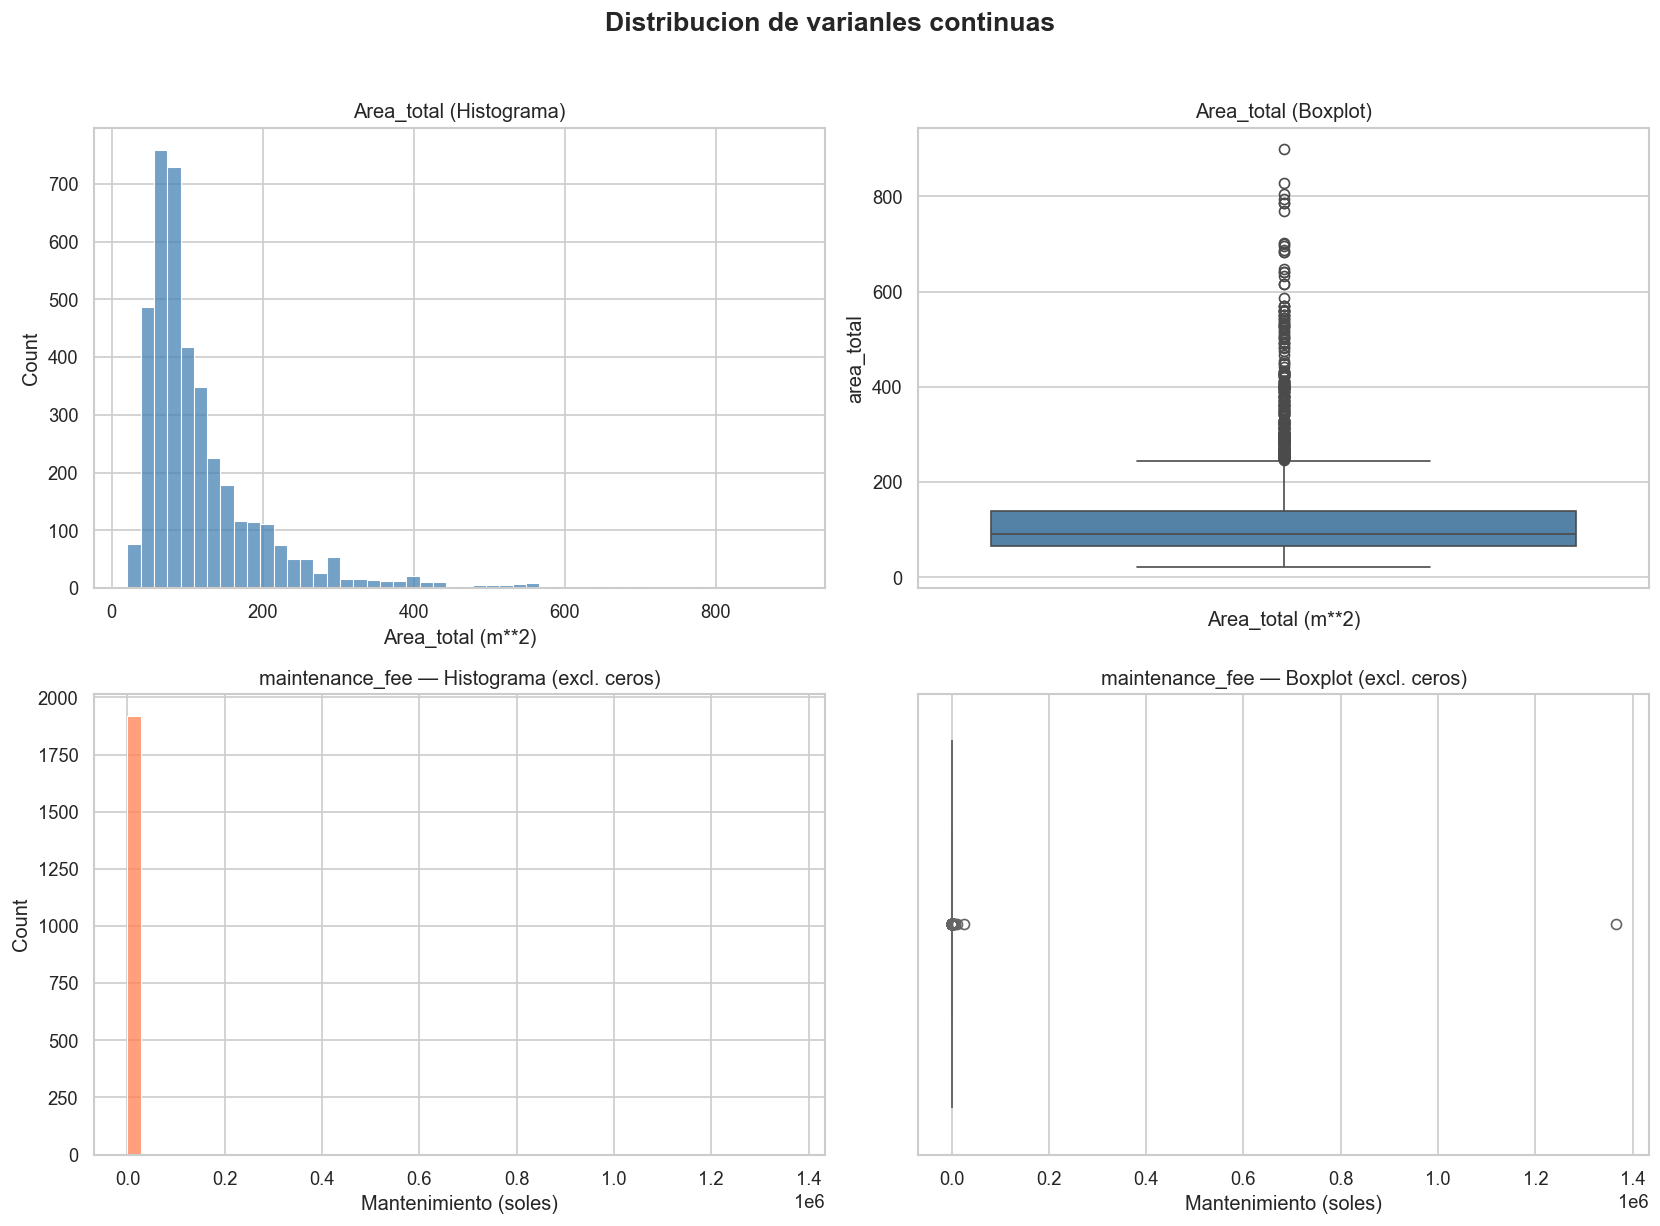

In [19]:
#Distribucion de variables numericas continuas

fig, axes = plt.subplots(2,2, figsize = (14,10))
fig.suptitle("Distribucion de varianles continuas", fontsize=16, fontweight="bold", y=1.02)

#Area total 
sns.histplot(df["area_total"], bins=50, ax=axes[0,0], color= "steelblue")
axes[0,0].set_title("Area_total (Histograma)")
axes[0,0].set_xlabel("Area_total (m**2)")

sns.boxplot(df["area_total"], ax=axes[0,1], color="steelblue")
axes[0,1].set_title("Area_total (Boxplot)")
axes[0,1].set_xlabel("Area_total (m**2)")

#Maintenance_fee (excluimos los 0)
maint_nonzero = df[df["maintenance_fee"] > 0]["maintenance_fee"]

sns.histplot(maint_nonzero, bins=50, ax=axes[1, 0], color="coral")
axes[1, 0].set_title("maintenance_fee — Histograma (excl. ceros)")
axes[1, 0].set_xlabel("Mantenimiento (soles)")

sns.boxplot(x=maint_nonzero, ax=axes[1, 1], color="coral")
axes[1, 1].set_title("maintenance_fee — Boxplot (excl. ceros)")
axes[1, 1].set_xlabel("Mantenimiento (soles)")

plt.tight_layout()
plt.show()